In [280]:
import numpy as np
import scipy.special



In [281]:
def modmc1(m, q, x):
    return scipy.special.mathieu_modcem1(m, q, x)
def modmc2(m, q, x):
    return scipy.special.mathieu_modcem2(m, q, x)

def modms1(m, q, x):
    return scipy.special.mathieu_modsem1(m, q, x)
def modms2(m, q, x):
    return scipy.special.mathieu_modsem2(m, q, x)

def mathieu_a(m, q):
    return scipy.special.mathieu_a(m, q)

def mathieu_b(m, q):
    return scipy.special.mathieu_b(m, q)



In [282]:
# Round trip modmc1
NN = 100
v = np.linspace(2,5,NN)
h = 5e-6
tol = 1e-3
MM = 50
qs = np.logspace(-4,4,10)



error = []
idx = 1
for q in qs:
    for m in range(MM):  
        fm3 = modmc1(m, q, v - 3 * h)[idx]
        fm2 = modmc1(m, q, v - 2 * h)[idx]
        fm1 = modmc1(m, q, v - h)[idx]
        fp1 = modmc1(m, q, v + h)[idx]
        fp2 = modmc1(m, q, v + 2 * h)[idx]
        fp3 = modmc1(m, q, v + 3 * h)[idx]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc1(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))

        error.append( stddev/np.linalg.norm(y, ord=2))
        if not np.isclose( l2norm , 0, atol=tol):
            
            print(f'm = {m}, q = {q}, error = {l2norm}')




m = 0, q = 0.0001, error = 0.9208188940744474
m = 1, q = 0.0001, error = 0.26589383464254734
m = 2, q = 0.0001, error = 0.0718267720697778
m = 3, q = 0.0001, error = 0.015011863936259796
m = 4, q = 0.0001, error = 0.0024860556248060255
m = 38, q = 0.0001, error = 0.0010721889074974684
m = 40, q = 0.0001, error = 0.009359363729264913
m = 42, q = 0.0001, error = 0.058147061605396747
m = 44, q = 0.0001, error = 0.19957902593515384
m = 45, q = 0.0001, error = 0.005815038764243554
m = 46, q = 0.0001, error = 1.05674188937287
m = 47, q = 0.0001, error = 0.04672885734165031
m = 48, q = 0.0001, error = 8.580131796370171
m = 49, q = 0.0001, error = 0.20211407939255968
m = 0, q = 0.000774263682681127, error = 0.7377963501464324
m = 1, q = 0.000774263682681127, error = 0.3700716544738418
m = 2, q = 0.000774263682681127, error = 0.2441849878011834
m = 3, q = 0.000774263682681127, error = 0.15489636586193828
m = 4, q = 0.000774263682681127, error = 0.07916834890083721
m = 5, q = 0.00077426368268112

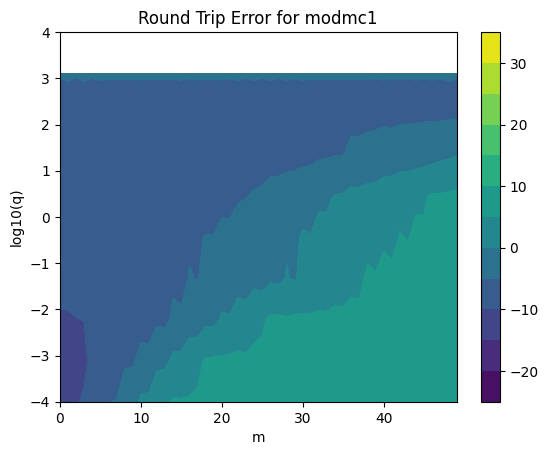

In [283]:
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize


M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)


levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modmc1")

plt.show()

In [284]:
# Round trip modmc2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 50
qs = np.logspace(-4,4,10)
error = []

for q in qs:
    for m in range(MM):    
        fm3 = modmc2(m, q, v - 3 * h)[1]
        fm2 = modmc2(m, q, v - 2 * h)[1]
        fm1 = modmc2(m, q, v - h)[1]
        fp1 = modmc2(m, q, v + h)[1]
        fp2 = modmc2(m, q, v + 2 * h)[1]
        fp3 = modmc2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc2(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) / np.sqrt(len(y))

        error.append(stddev/np.linalg.norm(y, ord=2))
        if not np.isclose( stddev/np.linalg.norm(y, ord=2), 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {stddev/np.linalg.norm(y, ord=2)}')



m = 0, q = 10000.0, error = nan
m = 1, q = 10000.0, error = nan
m = 2, q = 10000.0, error = nan
m = 3, q = 10000.0, error = nan
m = 4, q = 10000.0, error = nan
m = 5, q = 10000.0, error = nan
m = 6, q = 10000.0, error = nan
m = 7, q = 10000.0, error = nan
m = 8, q = 10000.0, error = nan
m = 9, q = 10000.0, error = nan
m = 10, q = 10000.0, error = nan
m = 11, q = 10000.0, error = nan
m = 12, q = 10000.0, error = nan
m = 13, q = 10000.0, error = nan
m = 14, q = 10000.0, error = nan
m = 15, q = 10000.0, error = nan
m = 16, q = 10000.0, error = nan
m = 17, q = 10000.0, error = nan
m = 18, q = 10000.0, error = nan
m = 19, q = 10000.0, error = nan
m = 20, q = 10000.0, error = nan
m = 21, q = 10000.0, error = nan
m = 22, q = 10000.0, error = nan
m = 23, q = 10000.0, error = nan
m = 24, q = 10000.0, error = nan
m = 25, q = 10000.0, error = nan
m = 26, q = 10000.0, error = nan
m = 27, q = 10000.0, error = nan
m = 28, q = 10000.0, error = nan
m = 29, q = 10000.0, error = nan
m = 30, q = 10000.0,

1.9932963604778475e-11
[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]


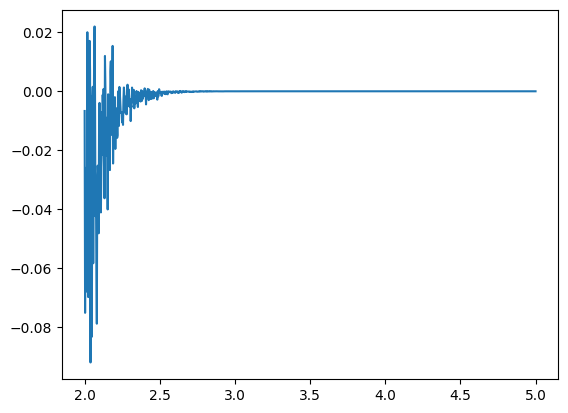

In [285]:
v = np.linspace(2,5,1000)

m = 9
q = 0.01
fm3 = modmc2(m, q, v - 3 * h)[1]
fm2 = modmc2(m, q, v - 2 * h)[1]
fm1 = modmc2(m, q, v - h)[1]
fp1 = modmc2(m, q, v + h)[1]
fp2 = modmc2(m, q, v + 2 * h)[1]
fp3 = modmc2(m, q, v + 3 * h)[1]

ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

[y,yd] = modmc2(m,q,v)
a = mathieu_a(m,q)

r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y

print(np.std(r)/ np.linalg.norm(y, ord=2))
plt.plot(v, r)


a = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print(a.reshape(5, 2))

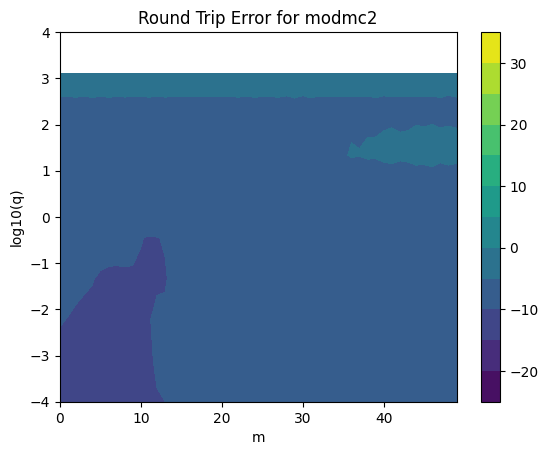

In [286]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)

levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modmc2")

plt.show()
# fig, ax = plt.subplots()
# im = ax.pcolormesh(range(MM), np.log10(qs), np.log10(error_array), cmap='viridis')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('Value')

# ax.set_title("Round Trip Error for modmc2")
# ax.set_xlabel("m")
# ax.set_ylabel("log10(q)")

# plt.show()

In [287]:
import math
# Round trip modms1

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for q in qs:
    for m in range(MM):  
        fm3 = modms1(m, q, v - 3 * h)[1]
        fm2 = modms1(m, q, v - 2 * h)[1]
        fm1 = modms1(m, q, v - h)[1]
        fp1 = modms1(m, q, v + h)[1]
        fp2 = modms1(m, q, v + 2 * h)[1]
        fp3 = modms1(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms1(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) 

        
        error.append(stddev / l2norm)
        if not np.isclose( stddev/ l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {l2norm}')



m = 0, q = 0.0001, error = nan
m = 6, q = 0.0001, error = 0.00038195381580700684
m = 8, q = 0.0001, error = 1.646727036295989e-05
m = 9, q = 0.0001, error = 2.755584366110699e-07
m = 10, q = 0.0001, error = 7.624720809402724e-06
m = 11, q = 0.0001, error = 1.2922740591430605e-09
m = 12, q = 0.0001, error = 0.00047653711920764665
m = 13, q = 0.0001, error = 4.275052046704242e-12
m = 14, q = 0.0001, error = 0.0011565279946569678
m = 15, q = 0.0001, error = 1.2207886318741463e-12
m = 16, q = 0.0001, error = 0.0026396694799782077
m = 17, q = 0.0001, error = 5.9081360151274375e-12
m = 18, q = 0.0001, error = 0.053423735017700445
m = 19, q = 0.0001, error = 2.7831640774523628e-11
m = 20, q = 0.0001, error = 0.31309698549441506
m = 21, q = 0.0001, error = 1.3273513966967606e-10
m = 22, q = 0.0001, error = 0.22973977628480377
m = 23, q = 0.0001, error = 7.589076381194459e-10
m = 24, q = 0.0001, error = 7.018498898496189
m = 25, q = 0.0001, error = 4.355136498465372e-09
m = 26, q = 0.0001, erro

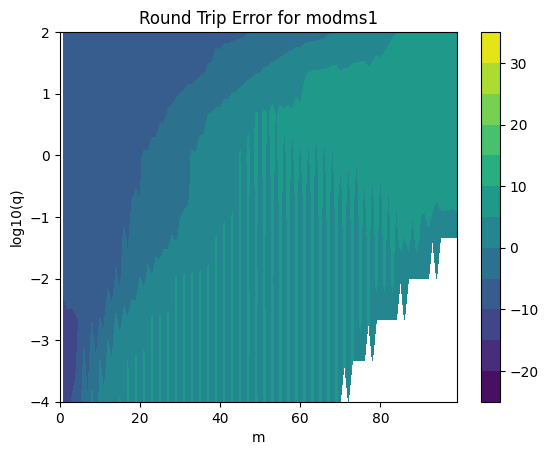

In [288]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)


levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modms1")
# fig, ax = plt.subplots()
# im = ax.pcolormesh(range(1, MM), np.log10(qs), error_array, cmap='viridis')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('Value')

# ax.set_title("Round Trip Error for modsm1")
# ax.set_xlabel("m")
# ax.set_ylabel("log10(q)")

plt.show()

In [289]:
# Round trip modms2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for q in qs:
    for m in range(MM):  
        fm3 = modms2(m, q, v - 3 * h)[1]
        fm2 = modms2(m, q, v - 2 * h)[1]
        fm1 = modms2(m, q, v - h)[1]
        fp1 = modms2(m, q, v + h)[1]
        fp2 = modms2(m, q, v + 2 * h)[1]
        fp3 = modms2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms2(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2) 
        error.append( stddev / l2norm)

        if not np.isclose(stddev / l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = { l2norm}')



m = 0, q = 0.0001, error = nan
m = 58, q = 0.0001, error = inf
m = 59, q = 0.0001, error = inf
m = 60, q = 0.0001, error = inf
m = 61, q = 0.0001, error = inf
m = 62, q = 0.0001, error = inf
m = 63, q = 0.0001, error = inf
m = 64, q = 0.0001, error = inf
m = 65, q = 0.0001, error = inf
m = 66, q = 0.0001, error = inf
m = 67, q = 0.0001, error = inf
m = 68, q = 0.0001, error = inf
m = 69, q = 0.0001, error = inf
m = 70, q = 0.0001, error = inf
m = 71, q = 0.0001, error = nan
m = 72, q = 0.0001, error = inf
m = 73, q = 0.0001, error = nan
m = 74, q = 0.0001, error = nan
m = 75, q = 0.0001, error = nan
m = 76, q = 0.0001, error = nan
m = 77, q = 0.0001, error = nan
m = 78, q = 0.0001, error = nan
m = 79, q = 0.0001, error = nan
m = 80, q = 0.0001, error = nan
m = 81, q = 0.0001, error = nan
m = 82, q = 0.0001, error = nan
m = 83, q = 0.0001, error = nan
m = 84, q = 0.0001, error = nan
m = 85, q = 0.0001, error = nan
m = 86, q = 0.0001, error = nan
m = 87, q = 0.0001, error = nan
m = 88, q

/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_15000/1798635968.py:28: RuntimeWarning: invalid value encountered in scalar divide
  error.append( stddev / l2norm)
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_15000/1798635968.py:30: RuntimeWarning: invalid value encountered in scalar divide
  if not np.isclose(stddev / l2norm , 0, atol=tol):
/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/_core/_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_15000/3443520812.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')


Text(0.5, 1.0, 'Round Trip Error for modms2')

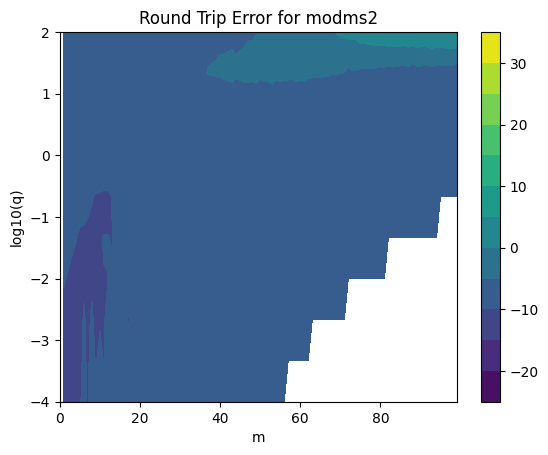

In [290]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)

levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for modms2")
# fig, ax = plt.subplots()
# im = ax.pcolormesh(range(1, MM), np.log10(qs), error_array, cmap='viridis')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('Value')

# ax.set_title(" Round Trip Error for modsm2")
# ax.set_xlabel("m")
# ax.set_ylabel("log10(q)")

# plt.show()

In [323]:
def cem(m, q, x):
    [y, yd] = scipy.special.mathieu_cem(m, q, (180/np.pi) * x)
    # yd = yd / (np.pi / 180)
    return (y, yd)


def mathieu_sem(m, q, x):
    return scipy.special.mathieu_sem(m, q, 180/np.pi*x)

In [ ]:
# Round trip cem
NN = 100
v = np.linspace(-np.pi, np.pi,NN)
h = 5e-6
tol = 1e-3
MM = 50
qs = np.logspace(-2,2,10)



error = []
idx = 1
for q in qs:
    for m in range(MM):  
        fm3 = cem(m, q, v - 3 * h)[idx]
        fm2 = cem(m, q, v - 2 * h)[idx]
        fm1 = cem(m, q, v - h)[idx]
        fp1 = cem(m, q, v + h)[idx]
        fp2 = cem(m, q, v + 2 * h)[idx]
        fp3 = cem(m, q, v + 3 * h)[idx]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = cem(m,q,v)
        a = mathieu_a(m,q)


        r = ydd/(h) + (a - 2 * q * np.cos(2*v )) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(r, ord=2) / np.sqrt(len(r))

        error.append(stddev/np.linalg.norm(r, ord=2))
        if not np.isclose( stddev/np.linalg.norm(r, ord=2) , 0, atol=tol):
            
            print(f'm = {m}, q = {q}, error = {stddev/np.linalg.norm(r, ord=2)}')




m = 0, q = 0.01, error = 0.09282711714070427
m = 1, q = 0.01, error = 0.08803818092918565
m = 2, q = 0.01, error = 0.09443048049594936
m = 3, q = 0.01, error = 0.09972914364170606
m = 4, q = 0.01, error = 0.09994294934576718
m = 5, q = 0.01, error = 0.09998059816286799
m = 6, q = 0.01, error = 0.09941481050566907
m = 7, q = 0.01, error = 0.09817405775572308
m = 8, q = 0.01, error = 0.09996763580018103
m = 9, q = 0.01, error = 0.09984750207258353
m = 10, q = 0.01, error = 0.09994652488216793
m = 11, q = 0.01, error = 0.09995444262745286
m = 12, q = 0.01, error = 0.09999680111557496
m = 13, q = 0.01, error = 0.09999541610289218
m = 14, q = 0.01, error = 0.09660482625588729
m = 15, q = 0.01, error = 0.09976119572175306
m = 16, q = 0.01, error = 0.09868088098762355
m = 17, q = 0.01, error = 0.09949305010997984
m = 18, q = 0.01, error = 0.09834721585827833
m = 19, q = 0.01, error = 0.09981871787905869
m = 20, q = 0.01, error = 0.09981355153037073
m = 21, q = 0.01, error = 0.0999838190610752

Text(0.5, 1.0, 'Round Trip Error for cem')

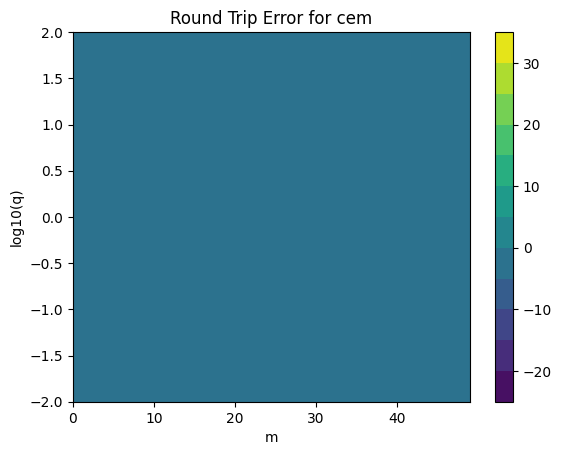

In [331]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)

levels = np.arange(-25, 36, 5)

plt.contourf(M, np.log10(Q), np.log10(error_array), levels=levels, cmap='viridis')
plt.colorbar()

plt.xlabel("m")
plt.ylabel("log10(q)")
plt.title("Round Trip Error for cem")
